# Kv 通道对比教程：NEURON、braincell 与误差分析

这个 tutorial 针对 `examples/ion_test` 里的 Kv 示例，分三步走：

1. 在 **NEURON** 中插入 `Kv` 通道，得到膜电压 `V`、钾电流 `ik`、门控变量 `n` 的时间曲线。
2. 在 **braincell** 中构造等价的单室模型，记录同样的三条曲线。
3. 使用 helper 脚本读取或重跑不同刺激条件下的 sweep，对比误差指标。


## 准备

本目录里已经有这几个关键文件：

- `kv.mod`：NEURON 的 Kv 机制
- `single_ion_compare_helper.py`：批量比较 helper
- `single_ion_compare_config.example.json`：刺激 sweep 配置
- `results/`：已经生成好的示例结果

如果你修改了 `kv.mod`，先在 `examples/ion_test` 目录下运行一次 `nrnivmodl`。下面的 notebook 默认优先复用现成结果。


In [1]:
from __future__ import annotations

import csv
import importlib.util
import json
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_example_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        direct = base
        nested = base / 'examples' / 'ion_test'
        if (direct / 'kv.mod').exists():
            return direct
        if (nested / 'kv.mod').exists():
            return nested
    raise FileNotFoundError('找不到 examples/ion_test 目录。')


ROOT = find_example_root()
HELPER_PATH = ROOT / 'single_ion_compare_helper.py'
spec = importlib.util.spec_from_file_location('single_ion_compare_helper', HELPER_PATH)
helper = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(helper)

ROOT


PosixPath('/home/swl/braincell/examples/ion_test')

## 1. NEURON：插入 Kv 通道并记录 `V / ik / n`

`single_ion_compare_helper.py` 内部会调用 `kv.mod`，建立单室 `soma`，插入：

- 被动漏电流 `pas`
- 钾通道 `Kv`
- `IClamp` 阶跃电流刺激

然后记录 `t`、`v`、`ik` 和门控变量 `n`。我们先跑一个单案例。


In [2]:
config_path = ROOT / 'single_ion_compare_config.example.json'
cfg = helper.load_config(config_path)
single_case = helper.expand_cases(cfg['sweep_grid'])[0]
single_case


{'case_id': 0,
 'tstop_ms': 50.0,
 'amp_nA': 0.01,
 'delay_ms': 0.0,
 'dur_ms': 20.0}

--No graphics will be displayed.


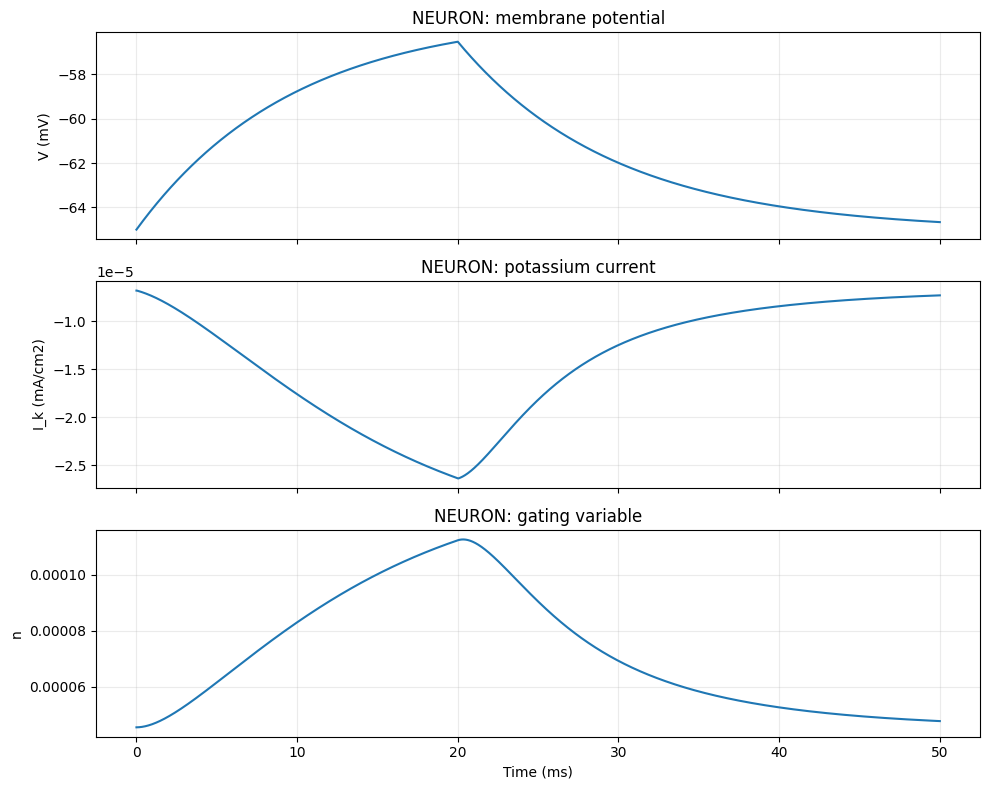

In [3]:
neuron_trace = helper.run_case_neuron(cfg, single_case)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(neuron_trace['t_ms'], neuron_trace['v_mV'])
axes[0].set_ylabel('V (mV)')
axes[0].set_title('NEURON: membrane potential')
axes[0].grid(alpha=0.25)

axes[1].plot(neuron_trace['t_ms'], neuron_trace['ik_mA_cm2'])
axes[1].set_ylabel('I_k (mA/cm2)')
axes[1].set_title('NEURON: potassium current')
axes[1].grid(alpha=0.25)

axes[2].plot(neuron_trace['t_ms'], neuron_trace['gate_n'])
axes[2].set_ylabel('n')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('NEURON: gating variable')
axes[2].grid(alpha=0.25)

fig.tight_layout()
plt.show()


## 2. braincell：构造等价单室模型

braincell 侧对应的是：

- `braincell.SingleCompartment`
- `braincell.ion.PotassiumFixed(E=-80 mV)`
- `braincell.channel.IK_Kv_test(g_max=...)`
- `braincell.channel.IL(...)`

helper 会把 `amp_nA` 自动换算成面积归一化后的电流密度，并在同一个时间窗口里驱动模型。


/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/braintools/surrogate.py:72: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  z = jnp.asarray(x >= 0, dtype=x.dtype)


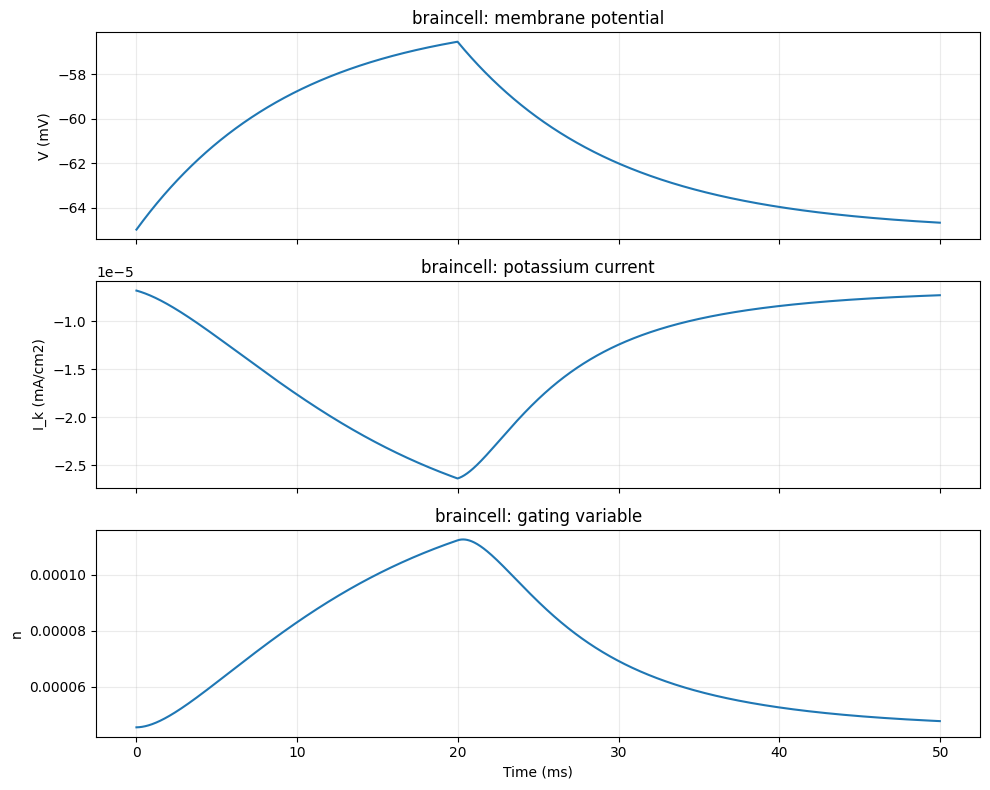

In [4]:
braincell_trace = helper.run_case_braincell(cfg, single_case)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(braincell_trace['t_ms'], braincell_trace['v_mV'])
axes[0].set_ylabel('V (mV)')
axes[0].set_title('braincell: membrane potential')
axes[0].grid(alpha=0.25)

axes[1].plot(braincell_trace['t_ms'], braincell_trace['ik_mA_cm2'])
axes[1].set_ylabel('I_k (mA/cm2)')
axes[1].set_title('braincell: potassium current')
axes[1].grid(alpha=0.25)

axes[2].plot(braincell_trace['t_ms'], braincell_trace['gate_n'])
axes[2].set_ylabel('n')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('braincell: gating variable')
axes[2].grid(alpha=0.25)

fig.tight_layout()
plt.show()


## 3. 单刺激下直接对齐比较

为了和 braincell 的 `g * (E - V)` 约定一致，helper 在 NEURON 侧把 `_ref_ik` 做了一次符号转换。这样两边的 `ik` 就可以直接重叠比较。


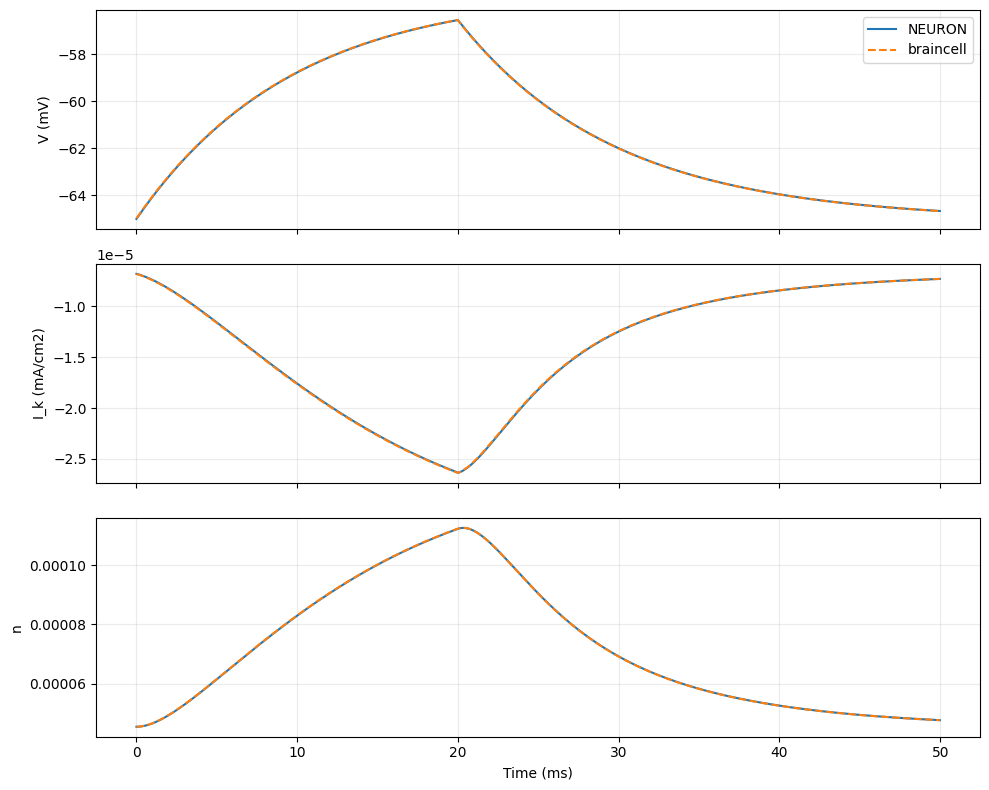

{'v_mV': {'mae': 0.010868600719348158,
  'rmse': 0.012290129939588173,
  'max_abs': 0.0247955322265625,
  'mean_bias': -0.0005028570533481939,
  'rel_mae_pct': 0.017923666315762362,
  'n_samples': 2000},
 'ik_mA_cm2': {'mae': 3.738935517926245e-08,
  'rmse': 4.305719099492766e-08,
  'max_abs': 7.532845603939363e-08,
  'mean_bias': 2.8724618237067287e-09,
  'rel_mae_pct': 0.2580912147277703,
  'n_samples': 2000},
 'gate_n': {'mae': 5.173935450518758e-08,
  'rmse': 5.80040608914326e-08,
  'max_abs': 8.919805125790772e-08,
  'mean_bias': -8.796198698099257e-09,
  'rel_mae_pct': 0.07004036110790579,
  'n_samples': 2000}}

In [5]:
comparison = helper.compare_case(cfg, single_case, ['v_mV', 'ik_mA_cm2', 'gate_n'])
labels = {'v_mV': 'V (mV)', 'ik_mA_cm2': 'I_k (mA/cm2)', 'gate_n': 'n'}

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, obs in zip(axes, ['v_mV', 'ik_mA_cm2', 'gate_n']):
    ax.plot(comparison['time_ms'], comparison['neuron'][obs], label='NEURON', linewidth=1.5)
    ax.plot(comparison['time_ms'], comparison['braincell'][obs], label='braincell', linestyle='--')
    ax.set_ylabel(labels[obs])
    ax.grid(alpha=0.25)
axes[0].legend()
axes[-1].set_xlabel('Time (ms)')
fig.tight_layout()
plt.show()

comparison['metrics']


## 4. 不同刺激下的误差比较

批量比较由 helper 脚本负责，默认读取当前目录下的 `results/`。如果你要刷新结果，可以手动调用下面这个函数：


In [6]:
def run_helper(config_path: Path = config_path, out_dir: Path | None = None, plot: bool = True) -> Path:
    out_dir = out_dir or (ROOT / 'results')
    cmd = [
        sys.executable,
        str(ROOT / 'single_ion_compare_helper.py'),
        '--config',
        str(config_path),
        '--out',
        str(out_dir),
    ]
    if not plot:
        cmd.append('--no-plot')
    subprocess.run(cmd, cwd=ROOT, check=True)
    return out_dir

# 需要重跑时再取消下面这行的注释。
# run_helper()


aggregate overall:
{
  "case_weighted_mean_rmse": 0.005079927958065736,
  "case_weighted_mean_mae": 0.003785286229741308
}

per observable:
{
  "v_mV": {
    "mae_mean": 0.011355691921432475,
    "rmse_mean": 0.015239559348331775,
    "max_abs_max": 0.049872682851571426,
    "rel_mae_pct_mean": 0.019908321044310267
  },
  "ik_mA_cm2": {
    "mae_mean": 7.337314215362984e-08,
    "rmse_mean": 1.0248549525361838e-07,
    "max_abs_max": 6.617985446821605e-07,
    "rel_mae_pct_mean": 0.25727291020475956
  },
  "gate_n": {
    "mae_mean": 9.339464929666456e-08,
    "rmse_mean": 1.2204037018268096e-07,
    "max_abs_max": 5.159597447541874e-07,
    "rel_mae_pct_mean": 0.07671378784576399
  }
}

worst case by mean rmse:
{
  "case_id": 3,
  "mean_rmse": 0.008185115524699525
}

top 5 cases by mean rmse:
{'case_id': 3, 'tstop_ms': 50.0, 'amp_nA': 0.02, 'delay_ms': 0.0, 'dur_ms': 20.0, 'mean_rmse': 0.008185115524699525}
{'case_id': 5, 'tstop_ms': 50.0, 'amp_nA': 0.02, 'delay_ms': 10.0, 'dur_ms': 2

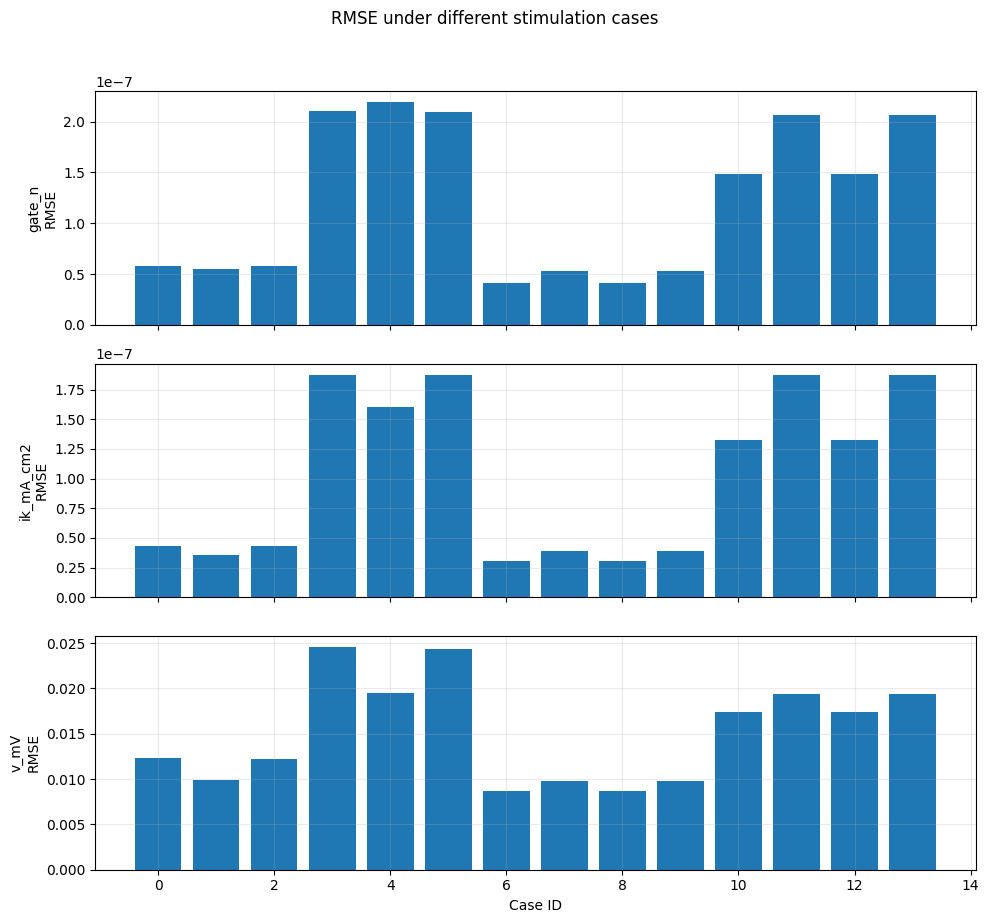

In [7]:
results_dir = ROOT / 'results'
aggregate = json.loads((results_dir / 'aggregate.json').read_text(encoding='utf-8'))
cases = json.loads((results_dir / 'cases.json').read_text(encoding='utf-8'))
with (results_dir / 'case_metrics.csv').open('r', encoding='utf-8', newline='') as f:
    rows = list(csv.DictReader(f))

ok_rows = [row for row in rows if row['status'] == 'ok']
case_by_id = {int(case['case_id']): case for case in cases}

print('aggregate overall:')
print(json.dumps(aggregate['overall'], indent=2, ensure_ascii=False))
print('\nper observable:')
print(json.dumps(aggregate['per_observable'], indent=2, ensure_ascii=False))
print('\nworst case by mean rmse:')
print(json.dumps(aggregate['worst_case_by_mean_rmse'], indent=2, ensure_ascii=False))

case_rmse = defaultdict(list)
for row in ok_rows:
    case_rmse[int(row['case_id'])].append(float(row['rmse']))

case_mean_rmse = []
for case_id, rmses in sorted(case_rmse.items()):
    item = dict(case_by_id[case_id])
    item['mean_rmse'] = float(np.mean(rmses))
    case_mean_rmse.append(item)

case_mean_rmse = sorted(case_mean_rmse, key=lambda item: item['mean_rmse'], reverse=True)
print('\ntop 5 cases by mean rmse:')
for item in case_mean_rmse[:5]:
    print(item)

observables = sorted({row['observable'] for row in ok_rows if row['observable']})
fig, axes = plt.subplots(len(observables), 1, figsize=(10, 3 * len(observables)), sharex=True)
if len(observables) == 1:
    axes = [axes]

for ax, obs in zip(axes, observables):
    obs_rows = sorted((row for row in ok_rows if row['observable'] == obs), key=lambda row: int(row['case_id']))
    case_ids = [int(row['case_id']) for row in obs_rows]
    rmses = [float(row['rmse']) for row in obs_rows]
    ax.bar(case_ids, rmses)
    ax.set_ylabel(f'{obs}\nRMSE')
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Case ID')
fig.suptitle('RMSE under different stimulation cases', y=1.02)
fig.tight_layout()
plt.show()


## 小结

这个目录里的 workflow 可以这样理解：

- notebook 负责把 **NEURON 建模流程**、**braincell 建模流程** 和 **误差结果解读** 串起来。
- `single_ion_compare_helper.py` 负责真正的 sweep 执行、结果落盘和逐 case 画图。
- `results/` 负责沉淀不同刺激下的误差统计，适合后续继续扩展更多通道或更多配置。
